In [1]:
%load_ext autoreload
%autoreload 1

In [1]:
import os
from unity_utils import UnityTranslator

dir = os.getcwd()
DATA_DIR = dir + '/data/transcript_6'
demos = UnityTranslator.get_from(DATA_DIR, resize = 512/1080)
## There are two types of dt --> for polling frames, and actual frame rate
# polling rate is relevant for computing time out of image frame
# but for computing the "index" from time --> should this index of the frame or the timestep of the demo --> should be the latter

fps: 60.0
frame_interval: 30
new_width 512, new_height: 910
Stored 32 frames.
total_tokens: 1794373
processed data in subdir: /Users/edward_kim/Desktop/narrated_demo/v2/data/transcript_6/demonstration0
fps: 60.0
frame_interval: 30
new_width 512, new_height: 910
Stored 47 frames.
total_tokens: 2744120
processed data in subdir: /Users/edward_kim/Desktop/narrated_demo/v2/data/transcript_6/demonstration1


In [2]:
demos[0].language = "Once your [teammate passes the ball to the coach] teammate passes the ball [coach receives ball], you return the [coach returns the pass to the teammate] pass to your teammate. Then go behind the opponent line to receive the ball [teammate passes to coach] [coach receives the ball]."

In [3]:
import json
from nlp_utils import *

inference_instructions = """
You are given: 
(1) a video as a sequence of image frames in a chronological order,
(2) a transcription of the video, and 
(3) a library of APIs.

In the video, an expert coach teaches you of a physical task in a particular scenario
which may involve physical interaction, or collaboration, with one or more people. 
The coach teaches you via physical demonstration (as you see in the video) and narration (as you find in the transcription).

Your job is to analyze the physical task. Specifically, you MUST ONLY analyze the behavior of the coach, 
i.e. what the coach teaches you to do. Do not analyze what others in the video should do. 

Through analysis, you should decompose the task into a set of subtasks 
and output their transition relations as a finite state machine (FSM) in a json file. 

In the FSM, a node should represent a subtask which consists of: 
(1) a unique integer identification number (e.g. 1, 2, 3) which you need to assign to each node
(2) a description of the subtask. This description MUST only pertain to the action of the coach, NOT others. 
(3) the name of the action API from the given library that is the most relevant to the action that the coach executes for this subtask.
This name is case-sensitive. Provide the exact name of the API. 
(4) a description of a boolean termination condition which, if is satisfied, then it means the subtask is completed.
(5) finally, an integer index of the image frame in the video, which satisfies the termination condition, 
i.e., referring to a snapshot capturing the moment when the termination condition is True.

An edge of the FSM should represent a transition relation between two nodes. 

An edge consists of: 
(1) a unique identification string (e.g. 'A', 'B') which you need to assign to each edge.
(2) the unique integer identification numbers of the NODES it is pointing from and to.  
(3) a description of a boolean precondition, which defines the condition for triggering a transition.
If the precondition is not specified in the transcription, output 'True' instead.
Also, if the precondition is semantically the same as the termination condition of the node it is pointing from, 
then set the precondition to be 'True'.

(4) finally, an integer index of the image frame in the video, which satisfies the precondition, 
i.e. referring to a snapshot capturing the moment when the precondition is True. 

Because you are outputting a FSM, there must also be an "initial" edge pointing to the initial node of the FSM. 
For this initial edge, the unique integer identification numbers of the node it is pointing from must be -1.

The nodes and the edges MUST be given as lists, respectively, in the json in the following format. 

{
    'nodes': [
        {
            'id': int,  // Unique identifier for the node, i.e. subtask
            'info': str,  // Description of the subtask
            'action': str,  // Provide a case-sensitive, exact name of the action API from the given library
            'termination': str,  // the condition for completing the subtask
            'keyframe': int, // index of the frame in which the termination condition is satisfied
        }
    ],
    "edges": [
        {
            'id': int,  // Unique identifier for the condition edge
            'from': int,  // ID of the previous node
            'to': int,  // ID of the next node
            'precondition': str,  // Condition under which the transition happens
            'keyframe': int, // index of the frame in which the precondition is satisfied
        }
    ]
}

"""
dir = os.getcwd()
filepath = dir + '/scenic_fc/actions.py'
with open(filepath, "r") as file:
    actionAPI = file.read()

# imgs_paths = demos[0].video.frame_dir

# base64Frames = []
# for im_path in imgs_paths:
#     base64_image = encode_image(im_path)
#     base64Frames.append(base64_image)

entries = [
    Chat.Entry(role='system', text=inference_instructions),
    Chat.Entry(role='user', text=f'Here is a transcription of the video: {demos[0].language}'),
    Chat.Entry(role='user', text=f'Here is a list of APIs which defines a set of actions: {actionAPI}'),
] + [Chat.Entry(role='user', text=f'This is a video as a sequence of image frames.', imgs_paths=demos[0].video.frame_dir)]


# TODO: Change to o1 for reasoning
chat = Chat(client, model='gpt-4o-mini')
response = json.loads(chat(entries, json=True))
print('Inference done.')

Inference done.


In [4]:
with open('fsm.json', 'w') as f:
    f.write(response)

TypeError: write() argument must be str, not dict

In [37]:
print(demos[0].language)
print(response)
for node in response['nodes']:
    node['keyframe'] = {'demo0': 1, 'demo1': 4}
for edge in response['edges']:
    edge['keyframe'] = {'demo0': 1, 'demo1': 4}

Once your [teammate passes the ball to the coach] teammate passes the ball [coach receives ball], you return the [coach returns the pass to the teammate] pass to your teammate. Then go behind the opponent line to receive the ball [teammate passes to coach] [coach receives the ball].
{'nodes': [{'id': 1, 'info': 'Coach receives the ball from the teammate.', 'action': 'pass', 'termination': 'Coach has received the ball from the teammate.', 'keyframe': {'demo0': 1, 'demo1': 4}}, {'id': 2, 'info': 'Coach returns the pass to the teammate.', 'action': 'pass', 'termination': 'Coach has passed the ball back to the teammate.', 'keyframe': {'demo0': 1, 'demo1': 4}}, {'id': 3, 'info': 'Coach moves behind the opponent line to receive the ball.', 'action': 'move_to', 'termination': 'Coach is behind the opponent line and ready to receive the ball.', 'keyframe': {'demo0': 1, 'demo1': 4}}, {'id': 4, 'info': 'Coach receives another ball from the teammate.', 'action': 'pass', 'termination': 'Coach has r

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


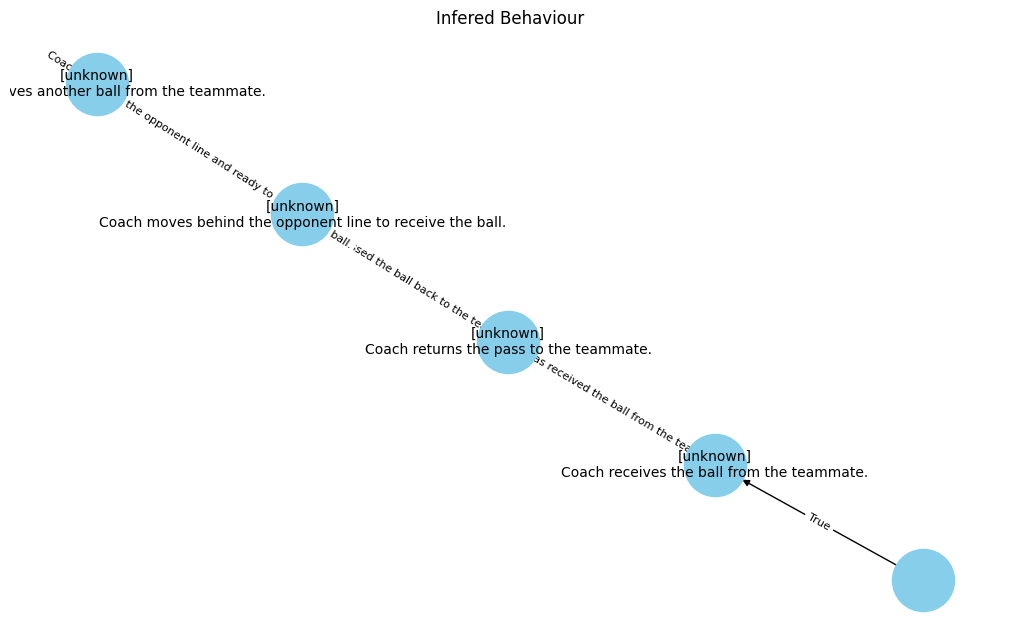

In [42]:
%load_ext autoreload
%autoreload 2

from synth_utils import Act
from scenic_fc.api import api

act = Act.from_dict(response, api)
act.show()

In [23]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

base64Frames = []
imgs_paths = demos[0].video.frame_dir

for im_path in imgs_paths:
    base64_image = encode_image(im_path)
    base64Frames.append(base64_image)

print(f"len(base64Frames): {}")

SYSTEM_INSTRUCTION = """
You are given a video and a list of descriptions of conditions in the chronological order they occur in the video. 
You task is to analyze the video and output a dictionary in a form of a json file, 
where the key is the string description of a condition in the list, 
and the value is the integer index of the image frame which captures the moment when the description is satisfied.
You must provide a key for each given condition in the dictionary. 
Also, because the conditions are provided in a chronological order, the integer index frame you provide for each condition
should be in an increasing order. 
"""

PROMPT_MESSAGES = [
    {
        "role": "user",
        "content": [
            "These are a sequence of image frames from a video in a chronological order.",
            *map(lambda x: {"image": x}, base64Frames),
        ],
    },
    {
        "role": "user",
        "content": [f"here are the list of conditions in the chronological order they occur in the video: {conditions}"]
    },
    {
        "role" : "system",
        "content": [SYSTEM_INSTRUCTION]
    }
]
params = {
    "model": "gpt-4o",
    "messages": PROMPT_MESSAGES,
    "max_tokens": 500,
}

result = client.chat.completions.create(**params)
print(result.choices[0].message.content)

```json
{
    "The teammate has passed the ball to the coach.": 2,
    "The coach has the ball successfully received.": 3,
    "Coach has received the ball.": 3,
    "The coach has successfully passed the ball back.": 6,
    "Coach has passed the ball back successfully.": 7,
    "The coach is behind the opponent line.": 16,
    "The coach is behind the opponent line.": 16,
    "The coach has received the ball.": 18
}
```


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image

modifications = []
for i, t in enumerate(act.nodes):

    print(f'{i + 1}/{len(act.nodes)}')
    print()
    print(t)
    print('Termination:', t.termination.info)
    print('Infered keyframe:', t.t)
    
    plt.imshow(demo.video[demo.video.t_for(t.t[''])])
    plt.axis('off')
    plt.show()

    manual_keyframe = input('Type the index (0-indexed) of keyframe to modify it or return to continue.')
    if manual_keyframe != '' and int(manual_keyframe) < len(demo.video.frame_dir):
        t.keyframe = manual_keyframe
        modifications += [f'[Task {i + 1}] Modified keyframe: {t.original.keyframe} -> {t.keyframe}']

    clear_output(wait=False)

if not len(modifications):
    print('No modifications.')
for mod in modifications:
    print(mod)

In [41]:
print(api)

{<API.actions: 'actions'>: {'MoveTo': <class 'scenic_fc.actions.MoveTo'>, 'Pass': <class 'scenic_fc.actions.Pass'>, 'Wait': <class 'scenic_fc.actions.Wait'>}, <API.constraints: 'constraints'>: {'in_zone': <class 'scenic_fc.constraints.InZone'>, 'has_angle_of_pass': <class 'scenic_fc.constraints.HasAngleOfPass'>, 'has_ball_possession': <class 'scenic_fc.constraints.HasBallPossession'>, 'ahead_of_line': <class 'scenic_fc.constraints.AheadOfLine'>, 'behind_of_line': <class 'scenic_fc.constraints.BehindOfLine'>, 'distance_to_object': <class 'scenic_fc.constraints.DistanceToObject'>}, <API.color_map: 'color_map'>: <function type_to_color at 0x141da2200>}


In [40]:
%load_ext autoreload
%autoreload 2

from synth_utils import Synth

pipe = Synth(act, demos, api)
pipe.run()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{'id': 'distance_teammate_coach_less_than', 'constraint': 'distance_to_object', 'args': {'fromObj': None, 'toObj': None, 'min': 0.0, 'max': 1.0, 'operator': 'less_than'}}
{'id': 'has_ball_possession_coach', 'constraint': 'has_ball_possession', 'args': {'obj': 'coach'}}


NameError: name 'demo' is not defined

In [ ]:
%load_ext autoreload
%autoreload 2

program = pipe.to_dict()
print(json.dumps(program, indent=4))

In [ ]:
%load_ext autoreload
%autoreload 2

from scenic_fc.constraints import DistanceToObject
from synth_utils import Constraint, Condition
from api_utils import API

API_REF = 'distance_to_object'
ARGS = {
    'toObj': 'teammate',
    'fromObj': 'coach'
}

condition = Condition()
condition.t = 2

constraint = Constraint('c1', condition, API_REF, ARGS, api[API.constraints])
constraint.synth(demo, api)

In [ ]:
round(2.3/0.5)